# MDI3003 — Experiment 08: Agricultural Predictive Analytics
**Rice Yield Prediction (core) + Crop-Label Classification (extension)**

Instructor: Dr. Durgesh Kumar, Assistant Professor (Senior), SCOPE

This notebook runs `lab08.py` (Appendix A implementation, reproduced exactly from the companion manual) end to end on the instructor-adapted canonical files in `data/`, then loads and displays the saved validation/test/error-analysis results and figures.

In [1]:
import subprocess, sys, json
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', None)

## 1. Regression core — Rice yield (West Bengal, 1997-2019)

Run validation, then open the locked test exactly once.

In [2]:
r = subprocess.run([sys.executable, 'lab08.py', '--config', 'config.json', '--stage', 'validate'],
                    capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

      model  seconds      MAE     RMSE        R2
     forest 0.142805 0.257820 0.341044  0.622120
ridge_trend 0.012748 0.281352 0.365838  0.565178
       tree 0.013796 0.308251 0.376377  0.539763
     median 0.015894 0.519766 0.661999 -0.423801
Selected: forest




In [3]:
r = subprocess.run([sys.executable, 'lab08.py', '--config', 'config.json', '--stage', 'test'],
                    capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

Final evaluation saved. Inspect failures; do not tune on these results.




### Validation results

In [4]:
pd.read_csv('outputs/core/Lab08_Validation_Results.csv')

,model,seconds,MAE,RMSE,R2
0,forest,0.142805,0.257820,0.341044,0.622120
1,ridge_trend,0.012748,0.281352,0.365838,0.565178
2,tree,0.013796,0.308251,0.376377,0.539763
3,median,0.015894,0.519766,0.661999,-0.423801


### Locked-test results (selected model vs. predeclared median baseline)

In [5]:
pd.read_csv('outputs/core/Lab08_Test_Results.csv')

,model,MAE,RMSE,R2,batch_inference_seconds
0,forest,0.363722,0.447465,0.401599,0.01768
1,median,0.616641,0.740173,-0.637349,NaN


### Split manifest summary

In [6]:
sm = pd.read_csv('outputs/core/artifacts/split_manifest.csv')
df = pd.read_csv('data/rice_canonical.csv')
m = sm.merge(df, on='row_id')
m.groupby('split').agg(years=('year', lambda x: f'{x.min()}-{x.max()}'), rows=('row_id','count'), districts=('district','nunique'))

,years,rows,districts
split,,,
test,2018-2019,128,22
train,1997-2015,1023,18
validation,2016-2017,128,22


### Development-only rolling origins (three one-year cutoffs)

In [7]:
pd.read_csv('outputs/core/artifacts/rolling_origins.csv')

,origin,model,training_max_year,n,MAE,RMSE,R2
0,2015,median,2014,54,0.557037,0.675198,-0.286239
1,2015,ridge_trend,2014,54,0.336983,0.431678,0.474252
2,2015,tree,2014,54,0.381116,0.453393,0.420026
3,2015,forest,2014,54,0.263854,0.376786,0.599457
4,2016,median,2015,64,0.508594,0.650880,-0.400188
5,2016,ridge_trend,2015,64,0.298070,0.400634,0.469506
6,2016,tree,2015,64,0.321943,0.401219,0.467958
7,2016,forest,2015,64,0.270791,0.369100,0.549730
8,2017,median,2016,64,0.522500,0.662016,-0.401625
9,2017,ridge_trend,2016,64,0.236389,0.295329,0.721063


### Year-by-year locked-test robustness

In [8]:
pd.read_csv('outputs/core/artifacts/year_robustness.csv')

,year,n,MAE,RMSE,R2
0,2018,64,0.357582,0.423025,0.381771
1,2019,64,0.369862,0.470637,0.413209


### Five largest locked-test errors

In [9]:
pd.read_csv('outputs/core/Lab08_Error_Analysis.csv')

,row_id,state,district,season,year,yield_t_ha,prediction,error,likely_cause,agricultural_consequence,mitigation
0,WB_R01207,West Bengal,Purba Bardhaman,Autumn,2019,1.10,3.069061,1.969061,NaN,NaN,NaN
1,WB_R00786,West Bengal,Kalimpong,Winter,2019,1.61,2.605379,0.995379,NaN,NaN,NaN
2,WB_R00916,West Bengal,Medinipur East,Autumn,2018,1.46,2.354047,0.894047,NaN,NaN,NaN
3,WB_R00785,West Bengal,Kalimpong,Winter,2018,1.76,2.605379,0.845379,NaN,NaN,NaN
4,WB_R00851,West Bengal,Maldah,Summer,2018,4.48,3.669436,0.810564,NaN,NaN,NaN


### Figures (training EDA, validation comparison, locked-test actual-vs-predicted, residuals)

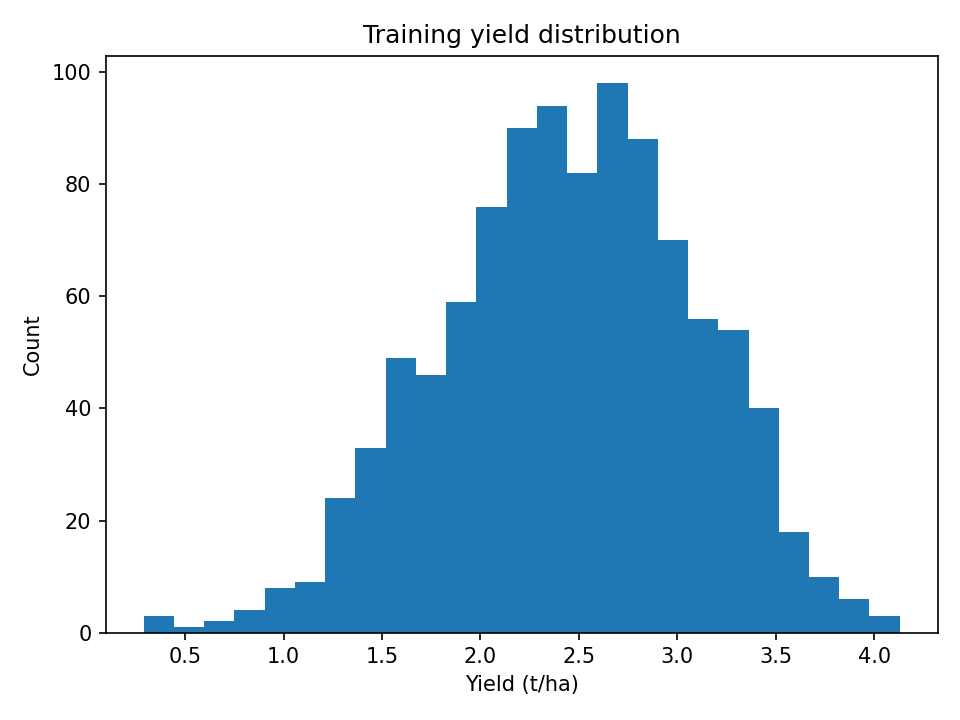

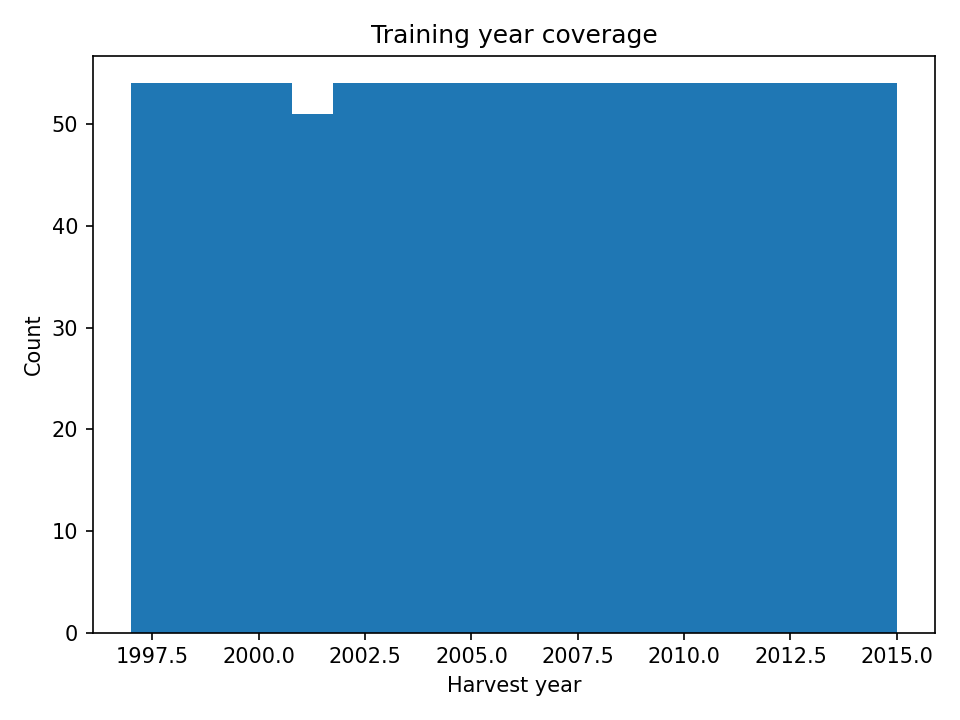

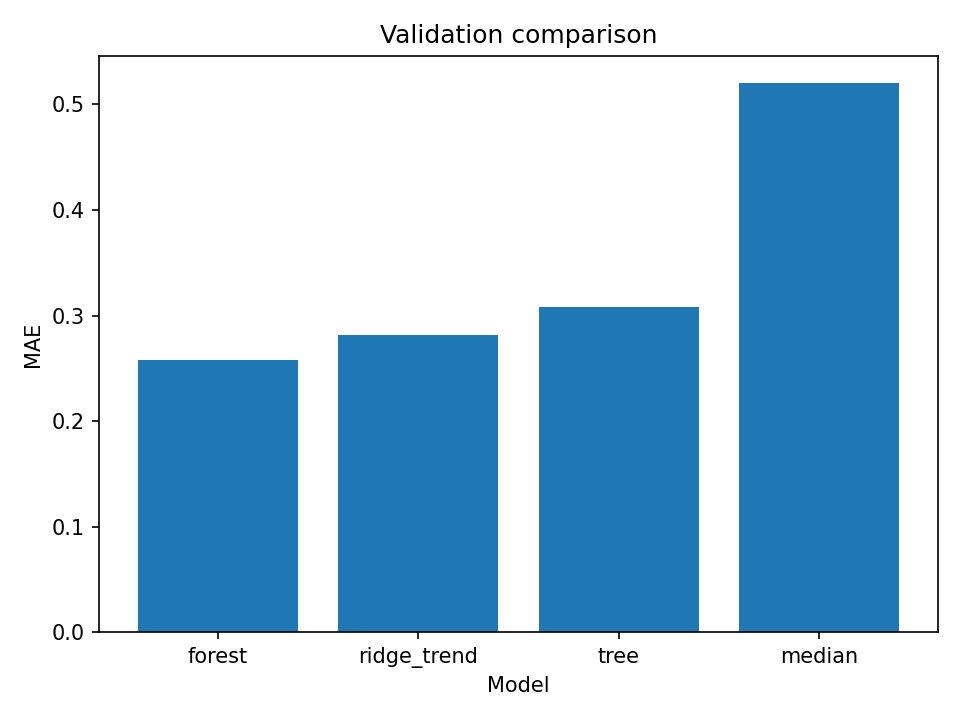

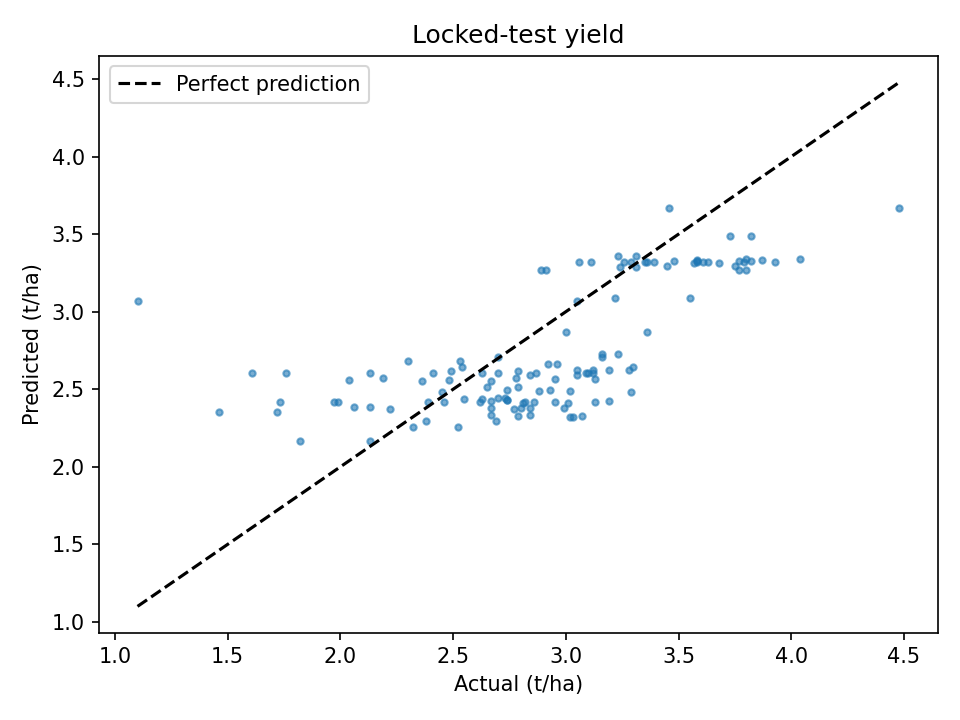

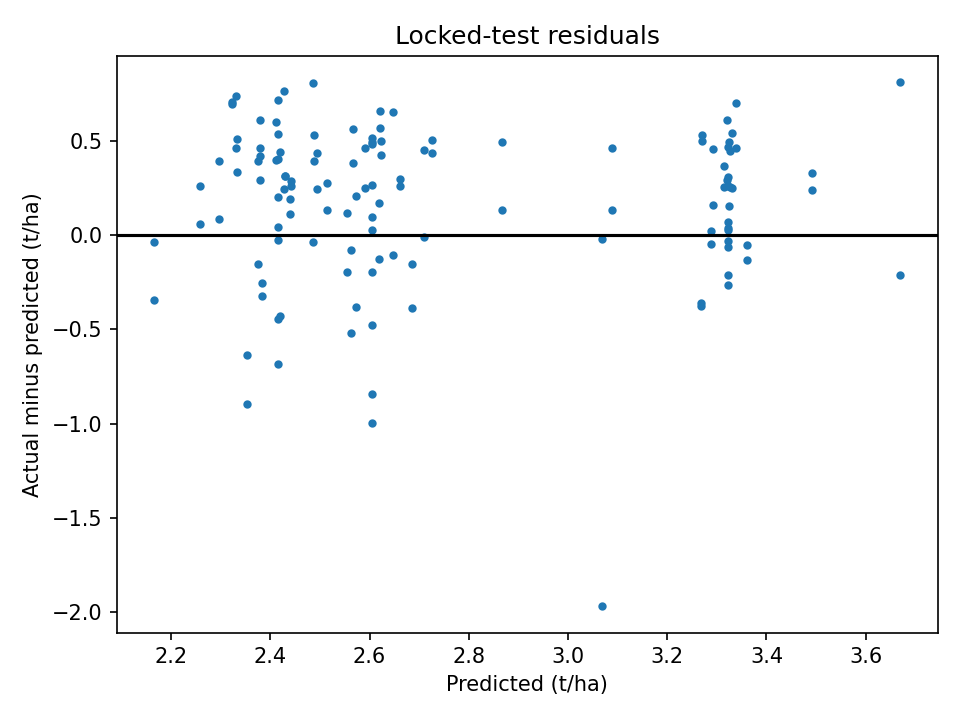

In [10]:
from IPython.display import Image, display
for f in ['target.png','feature.png','comparison.png','actual_predicted.png','residuals.png']:
    display(Image(filename=f'outputs/core/figures/{f}'))

### Acceptance record

In [11]:
json.load(open('outputs/core/artifacts/acceptance.json'))

{'split_disjoint': True,
 'reload_consistent': True,
 'valid_predictions': True,
 'data_hash_matched': True,
 'task': 'regression',
 'manual_failure_rows_available': 5}

## 2. Extension — Crop-label classification (independent D3-style dataset)

In [12]:
r = subprocess.run([sys.executable, 'lab08.py', '--config', 'config_classification.json', '--stage', 'validate'],
                    capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

   model  seconds  accuracy  macro_precision  macro_recall  macro_F1
  forest 0.164023  0.993182         0.993290      0.993182  0.993180
logistic 0.035643  0.972727         0.973016      0.972727  0.972596
majority 0.006658  0.045455         0.002066      0.045455  0.003953
Selected: forest




In [13]:
r = subprocess.run([sys.executable, 'lab08.py', '--config', 'config_classification.json', '--stage', 'test'],
                    capture_output=True, text=True)
print(r.stdout)
print(r.stderr)

Final evaluation saved. Inspect failures; do not tune on these results.




### Validation results

In [14]:
pd.read_csv('outputs/classification/Lab08_Validation_Results.csv')

,model,seconds,accuracy,macro_precision,macro_recall,macro_F1
0,forest,0.164023,0.993182,0.993290,0.993182,0.993180
1,logistic,0.035643,0.972727,0.973016,0.972727,0.972596
2,majority,0.006658,0.045455,0.002066,0.045455,0.003953


### Locked-test results

In [15]:
pd.read_csv('outputs/classification/Lab08_Test_Results.csv')

,model,accuracy,macro_precision,macro_recall,macro_F1,batch_inference_seconds
0,forest,0.990909,0.991907,0.990909,0.990869,0.014448
1,majority,0.045455,0.002066,0.045455,0.003953,NaN


### Per-class precision/recall/F1 (locked test)

In [16]:
pc = json.load(open('outputs/classification/artifacts/per_class.json'))
pd.DataFrame(pc).T

,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,20.000000
banana,1.000000,1.000000,1.000000,20.000000
blackgram,1.000000,1.000000,1.000000,20.000000
chickpea,1.000000,1.000000,1.000000,20.000000
coconut,1.000000,1.000000,1.000000,20.000000
coffee,1.000000,1.000000,1.000000,20.000000
cotton,1.000000,1.000000,1.000000,20.000000
grapes,1.000000,1.000000,1.000000,20.000000
jute,0.869565,1.000000,0.930233,20.000000
kidneybeans,1.000000,1.000000,1.000000,20.000000


### Figures (training label counts, pH distribution, validation comparison, confusion matrix)

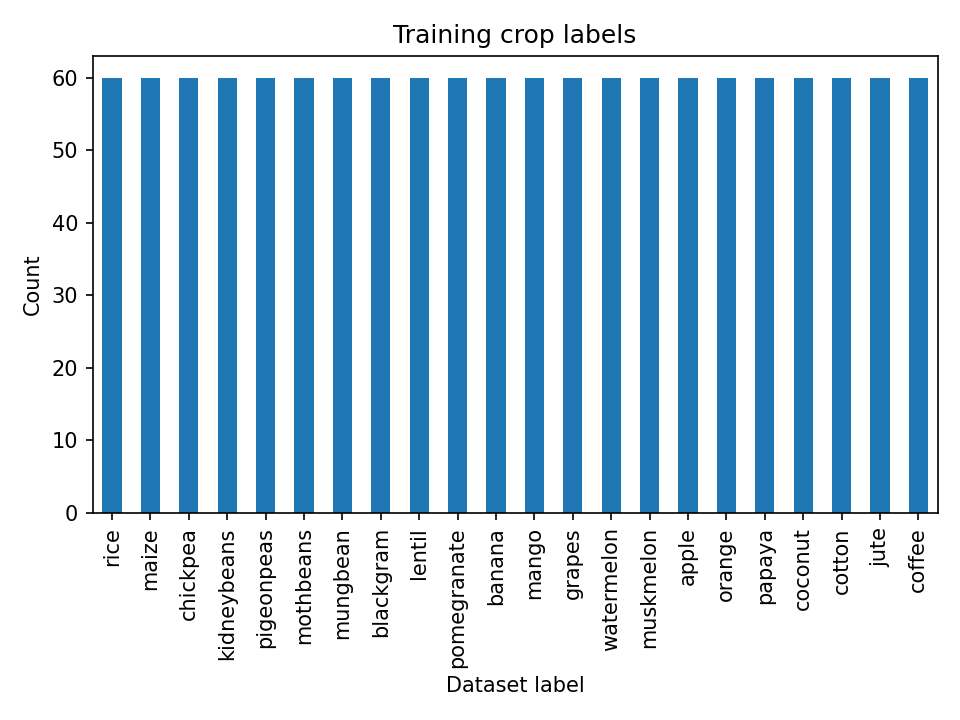

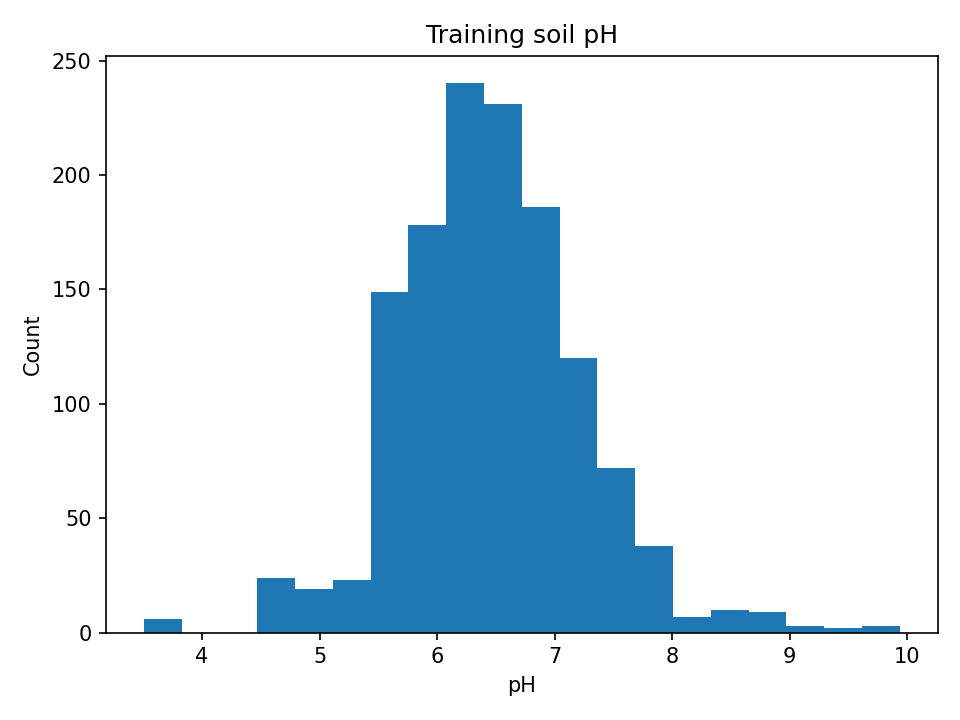

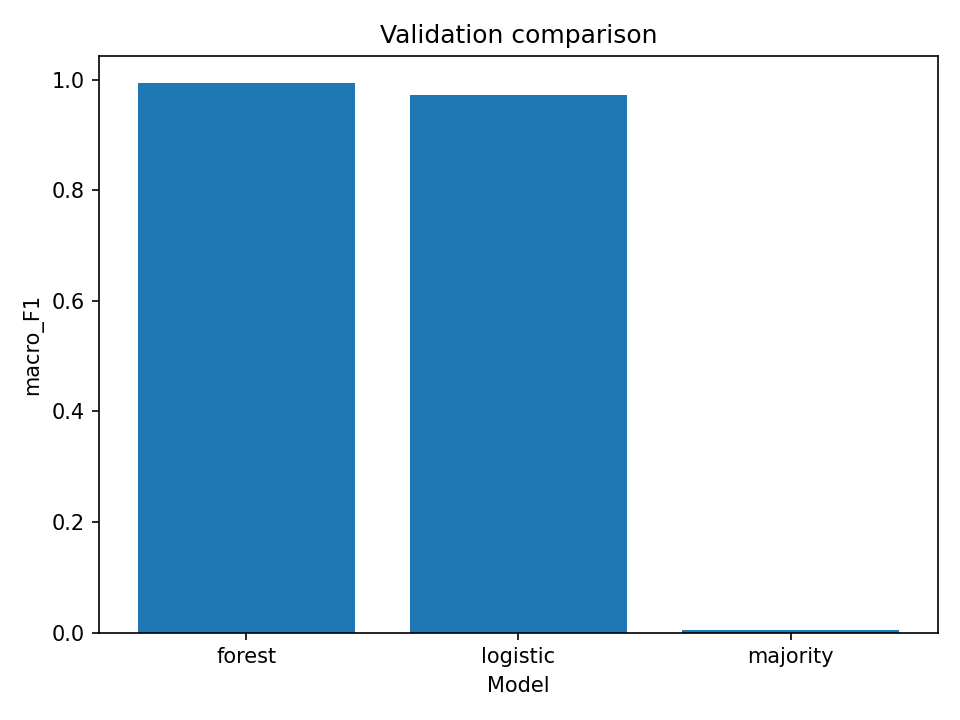

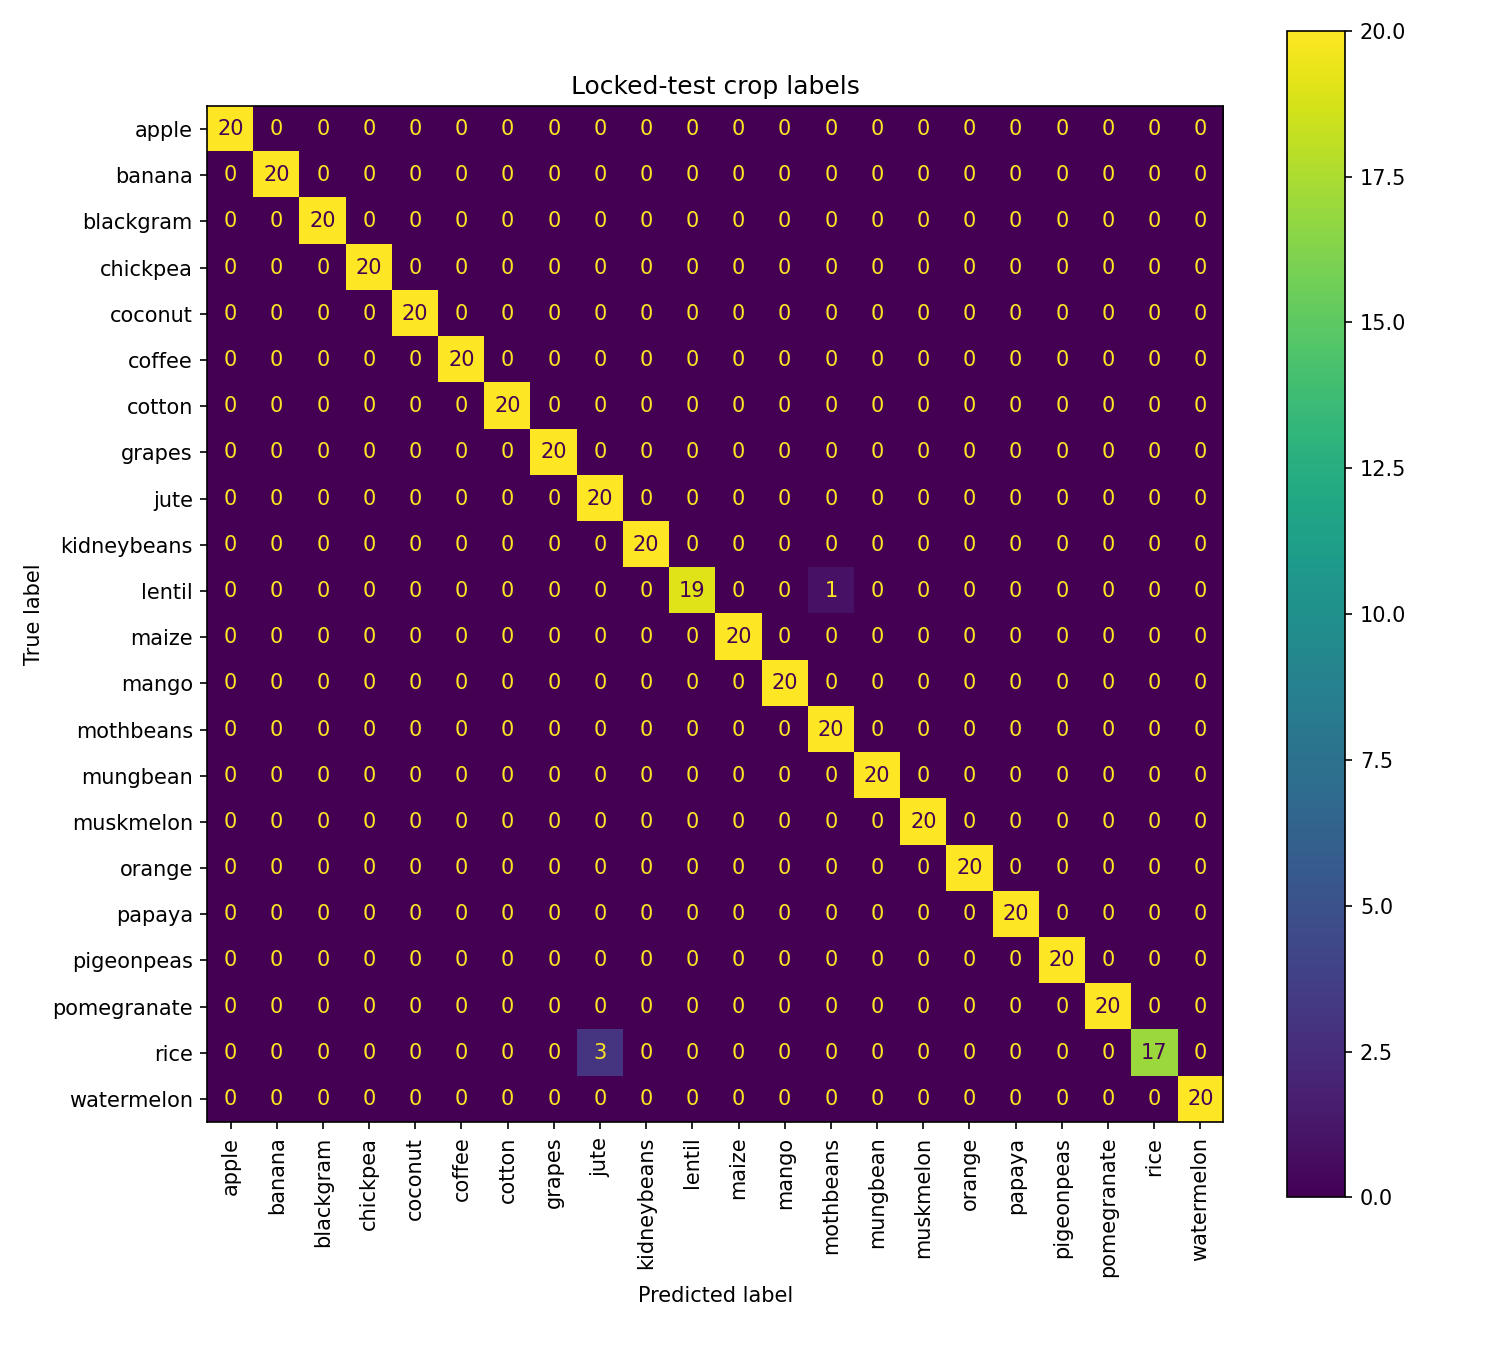

In [17]:
for f in ['target.png','feature.png','comparison.png','confusion.png']:
    display(Image(filename=f'outputs/classification/figures/{f}'))

## 3. Reload check — reproduce saved predictions from `selected_bundle.joblib`

Per the manual's Task 8: never load an untrusted joblib file — only the locally trained artifact from this run is loaded here.

In [18]:
import joblib, numpy as np
bundle = joblib.load('outputs/core/models/selected_bundle.joblib')
test_preds_saved = pd.read_csv('outputs/core/artifacts/test_predictions.csv')
df = pd.read_csv('data/rice_canonical.csv')
sm = pd.read_csv('outputs/core/artifacts/split_manifest.csv')
te = sm.merge(df, on='row_id')
te = te[te.split=='test']
reload_pred = bundle['pipeline'].predict(te[bundle['features']])
np.testing.assert_allclose(reload_pred, test_preds_saved['prediction'].to_numpy(), rtol=1e-8, atol=1e-8)
print('Reload check passed: predictions match within floating-point tolerance.')

Reload check passed: predictions match within floating-point tolerance.


## 4. Limitations and responsible-use note

See `Lab08_Report.docx` / PDF for the full problem contract, data governance record, error-cause hypotheses, limitations, and responsible-interpretation discussion. In brief: this is a retrospective, chronologically evaluated demonstration on a single-state Rice subset (core) and an independent, compact classification benchmark (extension); neither result should be read as a validated operational forecasting or crop-recommendation system.